# Classification model

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [7]:
df = pd.read_excel("..\\Archive of OSF Storage\\Raw score data\\Data for RI analysis\\RI_analysis_raw.xlsx")

print(df.shape)
print(df.columns)

(21588, 29)
Index(['skill.bracket', 'saves.ag', 'shots.ag', 'shots.conceded.ag',
       'Boost.used.ag', 'avg.boost.amount', 'amount.collected.ag',
       'count.collected.big.pads.ag', 'count.collected.small.pads.ag',
       'amount.stolen.ag', 'count.stolen.big.pads.ag',
       'count.stolen.small.pads.ag', '0.boost.time.ag', '100.boost.time.ag',
       'true.wastage', 'amount.overfill.total.ag', 'amount.overfill.stolen.ag',
       'real.speed.ag', 'percentage.slow.speed', 'percentage.supersonic.speed',
       'percentage.on.ground', 'percentage.high.in.air', 'avg.powerslide.time',
       'count.powerslide.ag', 'percentage.behind.ball',
       'percentage.defensive.third', 'percentage.offensive.third',
       'demos.inflicted.ag', 'demos.taken.ag'],
      dtype='object')


In [8]:
target_col = "skill.bracket"

feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols]
y = df[target_col]

print("X shape:", X.shape)

print(y.value_counts())

X shape: (21588, 28)
skill.bracket
gold       7226
diamond    7193
GC         4642
bronze     2527
Name: count, dtype: int64


In [9]:
# The paper used raw-score metrics only for RI analysis.
# For classification, R randomForest default is mtry = sqrt(number of predictors).

optimal_ntree = 964 

rf_clf = RandomForestClassifier(
    n_estimators=optimal_ntree,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=123
)

rf_clf.fit(X, y)

print("OOB accuracy:", rf_clf.oob_score_)

OOB accuracy: 0.7272558828979062


In [ ]:
# OOB confusion matrix and per-rank accuracy

oob_pred_indices = np.argmax(rf_clf.oob_decision_function_, axis=1)
class_labels = rf_clf.classes_
oob_predictions = class_labels[oob_pred_indices]

cm = confusion_matrix(y, oob_predictions, labels=class_labels)

confusion_df = pd.DataFrame(
    cm,
    index=[f"actual_{c}" for c in class_labels],
    columns=[f"predicted_{c}" for c in class_labels]
)

print(confusion_df)

per_rank_accuracy = {}

for rank in class_labels:
    mask = y == rank
    per_rank_accuracy[rank] = accuracy_score(y[mask], oob_predictions[mask])

per_rank_accuracy = pd.Series(per_rank_accuracy, name="OOB accuracy by rank")

print(per_rank_accuracy)

                predicted_GC  predicted_bronze  predicted_diamond  \
actual_GC               3422                 7               1169   
actual_bronze              4              1758                 51   
actual_diamond           747                15               5117   
actual_gold               33               307               1483   

                predicted_gold  
actual_GC                   44  
actual_bronze              714  
actual_diamond            1314  
actual_gold               5403  
GC         0.737182
bronze     0.695687
diamond    0.711386
gold       0.747717
Name: OOB accuracy by rank, dtype: float64


In [11]:
# Without this helper function below, the results were all 0 as the labels for predictions were integers while the true lables were strings.
def _decode_tree_predictions(pred, model=rf_clf):
        pred_arr = np.asarray(pred)

        if np.issubdtype(pred_arr.dtype, np.number):
            pred_int = pred_arr.astype(int)
            is_integer_like = np.all(np.isclose(pred_arr, pred_int))
            in_bounds = pred_int.size == 0 or (
                pred_int.min() >= 0 and pred_int.max() < len(model.classes_)
            )
            if is_integer_like and in_bounds:
                return model.classes_[pred_int]

        return pred_arr

def oob_mda_classification_rfpermute_like(model, X, y, n_repeats=1, random_state=123):

    rng = np.random.default_rng(random_state)

    X_np = X.to_numpy()
    y_np = y.to_numpy()
    n_samples, n_features = X_np.shape
    n_trees = len(model.estimators_)

    feature_names = list(X.columns)

    tree_feature_importances = np.full((n_trees, n_features), np.nan, dtype=float)

    for tree_idx, tree in enumerate(model.estimators_): # interate on every tree, get the out of bag samples, compute the baseline accuracy and then compare it to a permuted version for each feature
        bootstrap_indices = model.estimators_samples_[tree_idx]

        in_bag = np.zeros(n_samples, dtype=bool)
        in_bag[bootstrap_indices] = True
        oob_indices = np.flatnonzero(~in_bag)

        if oob_indices.size == 0:
            continue

        X_oob = X_np[oob_indices]
        y_oob = y_np[oob_indices]

        baseline_pred = _decode_tree_predictions(tree.predict(X_oob))
        baseline_acc = accuracy_score(y_oob, baseline_pred)

        for feature_idx in range(n_features):
            drops = []
            for _ in range(n_repeats):
                X_oob_perm = X_oob.copy()
                X_oob_perm[:, feature_idx] = rng.permutation(X_oob_perm[:, feature_idx])

                perm_pred = _decode_tree_predictions(tree.predict(X_oob_perm))
                perm_acc = accuracy_score(y_oob, perm_pred)

                drops.append(baseline_acc - perm_acc)

            tree_feature_importances[tree_idx, feature_idx] = float(np.mean(drops))

    importance_mean = np.mean(tree_feature_importances, axis=0)
    importance_sd = np.std(tree_feature_importances, axis=0, ddof=1)

    results = pd.DataFrame(
        {
            "feature": feature_names,
            "mean_decrease_accuracy": importance_mean,
            "importance_sd": importance_sd,
        }
    ).sort_values("mean_decrease_accuracy", ascending=False).reset_index(drop=True)

    return results


RI_importance = oob_mda_classification_rfpermute_like(
    model=rf_clf,
    X=X,
    y=y,
    n_repeats=1,
    random_state=123,
)

print(RI_importance.to_string(index=False, float_format=lambda v: f"{v:.12f}"))

                      feature  mean_decrease_accuracy  importance_sd
  percentage.supersonic.speed          0.099329796124 0.025697354409
         percentage.on.ground          0.043181266377 0.013496638035
          amount.collected.ag          0.033700626191 0.015692806051
          count.powerslide.ag          0.025684979742 0.010110234379
            shots.conceded.ag          0.018449536038 0.006327988241
        percentage.slow.speed          0.018155183041 0.008292899151
          avg.powerslide.time          0.017407804863 0.008287512986
                Boost.used.ag          0.016963357519 0.010498180710
count.collected.small.pads.ag          0.013482176621 0.005562218015
       percentage.behind.ball          0.013090111156 0.004699703405
                     shots.ag          0.012730153084 0.004916121772
            100.boost.time.ag          0.012081466920 0.005198343791
                real.speed.ag          0.011687192681 0.006462610980
                     saves.ag     

In [12]:
from tqdm.auto import tqdm

def rfpermute_classification_oob_minimal(
    X,
    y,
    ntree,
    n_permutations=50,
    random_state=123,
    rf_verbose=0,
):
    features = list(X.columns)
    rng = np.random.default_rng(random_state)

    observed_model = RandomForestClassifier(
        n_estimators=ntree,
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=random_state,
        verbose=rf_verbose,
    )

    observed_model.fit(X, y)

    observed_importance = (
        oob_mda_classification_rfpermute_like(
            model=observed_model,
            X=X,
            y=y,
            n_repeats=1,
            random_state=random_state,
        )
        .set_index("feature")
        .loc[features, "mean_decrease_accuracy"]
        .to_numpy()
    )

    null_importance = np.zeros((n_permutations, len(features)))

    permutation_iterator = tqdm(
        range(n_permutations),
        desc="Outcome permutations",
        total=n_permutations,
        dynamic_ncols=True,
        leave=True,
    )

    for i in permutation_iterator:
        permutation_iterator.set_postfix_str(f"completed={i + 1}/{n_permutations}")

        y_perm = pd.Series(
            rng.permutation(y.to_numpy()),
            index=y.index,
            name=y.name,
        )

        null_model = RandomForestClassifier(
            n_estimators=ntree,
            max_features="sqrt",
            bootstrap=True,
            oob_score=True,
            n_jobs=-1,
            random_state=int(rng.integers(0, 2**31 - 1)),
            verbose=rf_verbose,
        )

        null_model.fit(X, y_perm)

        null_importance[i, :] = (
            oob_mda_classification_rfpermute_like(
                model=null_model,
                X=X,
                y=y_perm,
                n_repeats=1,
                random_state=int(rng.integers(0, 2**31 - 1)),
            )
            .set_index("feature")
            .loc[features, "mean_decrease_accuracy"]
            .to_numpy()
        )

    p_values = (
        (null_importance >= observed_importance).sum(axis=0) + 1
    ) / (n_permutations + 1)

    RI_results = pd.DataFrame({
        "feature": features,
        "mean_decrease_accuracy": observed_importance,
        "p_value": p_values,
        "significant_p_0_05": p_values < 0.05,
    })

    RI_results = RI_results.sort_values(
        "mean_decrease_accuracy",
        ascending=False,
    ).reset_index(drop=True)

    return observed_model, RI_results

In [13]:
observed_model, RI_results = rfpermute_classification_oob_minimal(
    X=X,
    y=y,
    ntree=optimal_ntree,
    n_permutations=20,
    random_state=123,
    rf_verbose=1,
 )

print(RI_results)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 760 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 964 out of 964 | elapsed:    6.0s finished


Outcome permutations:   0%|          | 0/20 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 760 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 964 out of 964 | elapsed:    9.5s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 760 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 964 out of 964 | elapsed:    9.6s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed: 

                          feature  mean_decrease_accuracy   p_value  \
0     percentage.supersonic.speed                0.099330  0.047619   
1            percentage.on.ground                0.043181  0.047619   
2             amount.collected.ag                0.033701  0.047619   
3             count.powerslide.ag                0.025685  0.047619   
4               shots.conceded.ag                0.018450  0.047619   
5           percentage.slow.speed                0.018155  0.047619   
6             avg.powerslide.time                0.017408  0.047619   
7                   Boost.used.ag                0.016963  0.047619   
8   count.collected.small.pads.ag                0.013482  0.047619   
9          percentage.behind.ball                0.013090  0.047619   
10                       shots.ag                0.012730  0.047619   
11              100.boost.time.ag                0.012081  0.047619   
12                  real.speed.ag                0.011687  0.047619   
13    

A small comment here, since we are using permutation based p-values, and we opted to limit the amount of permutations to 20 due to computational cost.

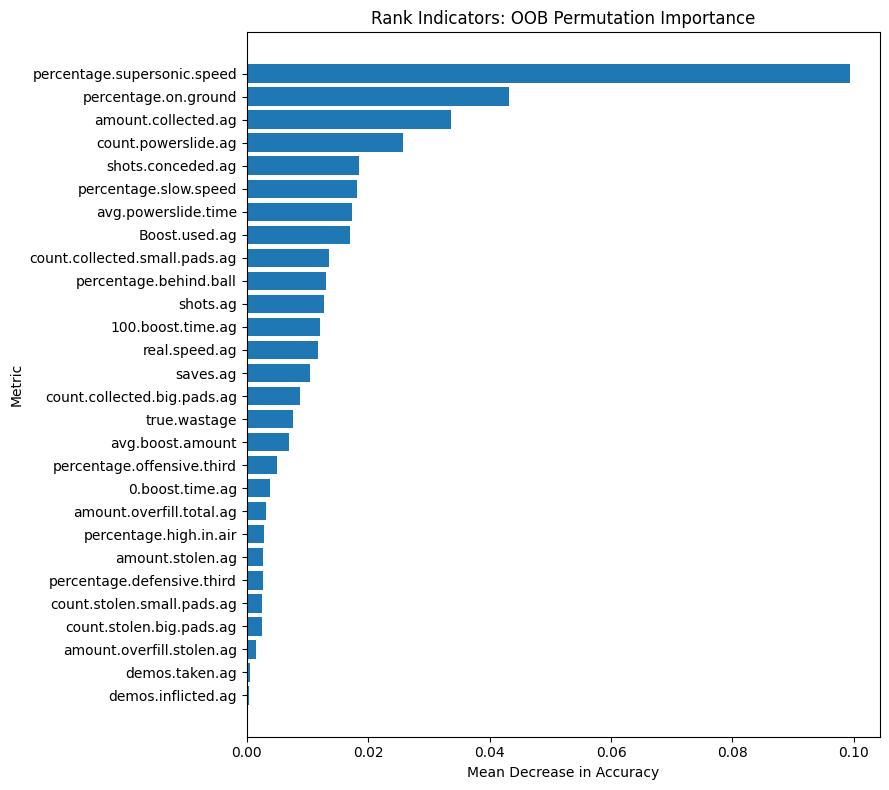

In [ ]:
import matplotlib.pyplot as plt

plot_data = RI_results.sort_values(
    "mean_decrease_accuracy",
    ascending=True
)

plt.figure(figsize=(9, 8))
plt.barh(
    plot_data["feature"],
    plot_data["mean_decrease_accuracy"]
)

plt.xlabel("Mean Decrease in Accuracy")
plt.ylabel("Metric")
plt.title("Rank Indicators: OOB Permutation Importance")

plt.tight_layout()
plt.savefig("../outputs/RI_mean_decrease_accuracy.png", dpi=300)
plt.show()